# Báo cáo huấn luyện: Phân loại loại xe thô (Ô tô / Xe máy / Xe tải)

Notebook thu hoạch: đọc lại artifact đã lưu từ `src/ml/train_vehicle_type_classifier.py`
(checkpoint, epoch-history JSON, run manifest). Notebook này không train lại, chỉ phân
tích và trực quan hóa kết quả đã có.

**Vì sao có notebook này:** trước đây loại xe thô (car/motorcycle/bus/truck) suy trực
tiếp từ nhãn lớp của YOLOv8n pretrained trên COCO (`predict_vehicle.detect_vehicle_crop`),
không train lại — sai khá nhiều với ảnh cận cảnh kiểu camera cổng chắn (đặc biệt xe máy).
Notebook này báo cáo kết quả của model phân loại **tự huấn luyện** thay thế bước đó.

**Dữ liệu:** `data/raw/kaggle_vn_plate_segment`, xem đầy đủ nguồn từng lớp và cách lọc
tại `src/ml/data_prep/prepare_vehicle_type_dataset.py`:
- `car`: `carlong_*` (cận cảnh camera gờ giảm tốc/barrier) **+ 92 ảnh** `Dieu_*`/`Hung_*`
  (đường phố, xem tay).
- `motorbike`: `greenpack_*` (cận cảnh CCTV cổng) **+ 128 ảnh** `Dieu_*`/`Hung_*`
  (đường phố, xem tay).
- `truck`: không có thư mục riêng — lọc từ nhóm ảnh phố hỗn hợp `Dieu_*`/`Hung_*` bằng
  YOLOv8n pretrained (dò ứng viên) rồi **xem tay từng ứng viên** (confidence của detector
  không đáng tin để lọc tự động — dương tính giả xuất hiện ở mọi mức điểm). Do đó lớp
  `truck` có ít ảnh hơn hẳn 2 lớp kia (73 so với 442/478) và chỉ có phong cách "đường phố",
  chưa có phong cách "cận cảnh cổng" (không có nguồn nào cho xe tải giống carlong_/greenpack_).
- Chưa có lớp `bus` ở bản này (thiếu ảnh cận cảnh kiểu camera cổng cho xe khách).

**Vì sao mỗi lớp car/motorbike có 2 nguồn thay vì 1:** lần train đầu tiên chỉ lấy car từ
`carlong_` và motorbike từ `greenpack_` (đúng 1 nguồn/camera mỗi lớp), đạt accuracy 100%
trên tập test — nhưng đó là ảo. Model học theo **phong cách ảnh/camera** thay vì hình dáng
xe: test trên 12 ảnh Dieu_/Hung_ ngoài tập train (biết chắc nhãn thật qua xem tay) thì
sai 12/13, mọi ảnh "đường phố" đều bị đoán thành `truck` — vì `truck` là lớp DUY NHẤT có
ảnh đường phố lúc đó. Sau khi bổ sung ảnh car/motorbike từ Dieu_/Hung_ (mục 7 bên dưới),
chạy lại đúng 12 ảnh đó: ResNet18 12/12 (100%), MobileNetV3-Small 11/12 (92%). Script kiểm
tra này được giữ lại ở `src/ml/sanity_check_vehicle_type_ood.py`.

2 kiến trúc so sánh: ResNet18, MobileNetV3-Small — cùng quy trình đã dùng cho model
kiểu dáng xe con (`train_vehicle_classifier.py`).

## 0. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve().parents[2] if (Path.cwd().name == "notebooks") else Path.cwd()
EXPERIMENTS_DIR = REPO_ROOT / "src" / "ml" / "experiments"
DATA_DIR = REPO_ROOT / "data" / "processed" / "vehicle-type"
FIG_DIR = REPO_ROOT / "docs" / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["resnet18", "mobilenet_v3_small"]
MODEL_LABELS = {"resnet18": "ResNet18", "mobilenet_v3_small": "MobileNetV3-Small"}
# Cặp màu categorical đã validate qua dataviz skill (CVD-safe, xem scripts/validate_palette.js)
MODEL_COLORS = {"resnet18": "#2a78d6", "mobilenet_v3_small": "#eb6834"}
CLASS_LABELS = {"car": "Ô tô", "motorbike": "Xe máy", "truck": "Xe tải"}

plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "font.size": 10,
})

manifest = json.loads((EXPERIMENTS_DIR / "type_run_manifest.json").read_text(encoding="utf-8"))
histories = {
    model: json.loads((EXPERIMENTS_DIR / f"type_{model}_history.json").read_text(encoding="utf-8"))
    for model in MODELS
}
print("Đã đọc manifest +", len(histories), "file history.")

Đã đọc manifest + 2 file history.


## 1. Thông số huấn luyện đã dùng

In [2]:
config_df = pd.DataFrame([
    ("Thiết bị", manifest["device"]),
    ("Optimizer", manifest["optimizer"]),
    ("Learning rate", manifest["lr"]),
    ("Batch size", manifest["batch_size"]),
    ("Epochs", manifest["epochs"]),
    ("Loss", manifest["loss"]),
    ("Augmentation", manifest["augmentation"]),
    ("Nguồn dữ liệu", manifest["data_source"]),
    ("Ghi chú", manifest["note"]),
], columns=["Thông số", "Giá trị"]).set_index("Thông số")
display(config_df.style.set_properties(**{"text-align": "left"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "left")]}]
).set_caption("Cấu hình huấn luyện"))

,Giá trị
Thông số,
Thiết bị,cuda (NVIDIA GeForce RTX 4070)
Optimizer,Adam
Learning rate,0.000100
Batch size,32
Epochs,15
Loss,"CrossEntropyLoss(weight=class_weights), trong so nghich ti le so mau moi lop (lop truck it anh hon nhieu, class_weights bu lai)"
Augmentation,"RandomResizedCrop(224, scale=0.8-1.0), RandomHorizontalFlip, RandomRotation(10), ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)"
Nguồn dữ liệu,"kaggle_vn_plate_segment: carlong_ (car, cong barrier), greenpack_ (motorbike, CCTV cong), 73 anh Dieu_/Hung_ da xem tay loc xe tai (xem prepare_vehicle_type_dataset.py)"
Ghi chú,"Thay the YOLOv8n pretrained COCO (khong train lai) dang dung trong predict_vehicle.detect_vehicle_crop de suy loai xe tho; YOLOv8n van dung de tim/cat vung xe, chi bo phan doc nhan lop COCO cua no."


## 2. Dữ liệu được chia thế nào

Đếm trực tiếp từ thư mục `data/processed/vehicle-type/` (không hard-code số). Lưu ý lớp
`truck` có ít ảnh hơn hẳn 2 lớp kia — xem phần 0 để biết lý do (73 ảnh so với 442/478 của
car/motorbike, và car/motorbike mỗi lớp trộn 2 nguồn/phong cách ảnh khác nhau).

In [3]:
def count_split(data_dir: Path) -> pd.DataFrame:
    rows = []
    for split in ("train", "valid", "test"):
        split_dir = data_dir / split
        if not split_dir.exists():
            continue
        for cls_dir in sorted(split_dir.iterdir()):
            n = len(list(cls_dir.glob("*.png"))) + len(list(cls_dir.glob("*.jpg")))
            rows.append({"split": split, "class": cls_dir.name, "n": n})
    return pd.DataFrame(rows)

counts_df = count_split(DATA_DIR)
pivot = counts_df.pivot(index="class", columns="split", values="n").fillna(0).astype(int)
pivot = pivot[["train", "valid", "test"]]
pivot = pivot.rename(index=CLASS_LABELS)
pivot.loc["TỔNG"] = pivot.sum()
display(
    pivot.style.background_gradient(cmap="Blues", subset=pd.IndexSlice[pivot.index[:-1], :])
    .format("{:,}")
    .set_caption(f"Phân bố lớp - tổng {int(counts_df['n'].sum()):,} ảnh")
)

split,train,valid,test
class,,,
Ô tô,309,66,67
Xe máy,335,72,71
Xe tải,51,11,11
TỔNG,695,149,149


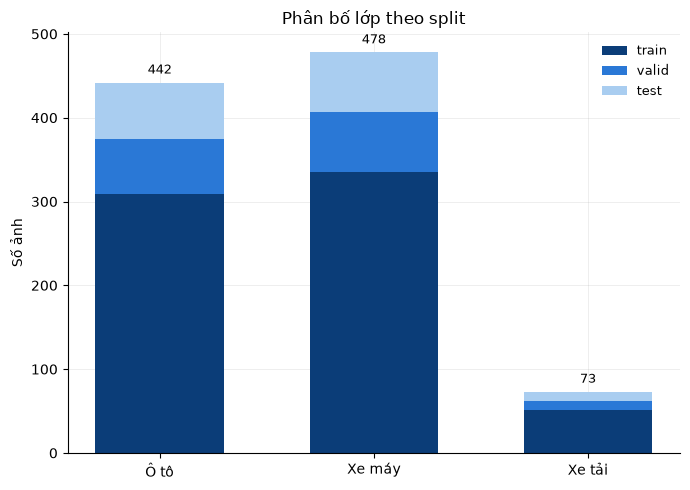

In [4]:
SPLIT_COLORS = {"train": "#0b3d78", "valid": "#2a78d6", "test": "#a9cdf0"}  # 1 hue, sáng->đậm

fig, ax = plt.subplots(figsize=(7, 5))
pv = counts_df.pivot(index="class", columns="split", values="n").fillna(0)[["train", "valid", "test"]]
pv = pv.rename(index=CLASS_LABELS)
bottom = np.zeros(len(pv))
for split in ("train", "valid", "test"):
    ax.bar(pv.index, pv[split], bottom=bottom, label=split, color=SPLIT_COLORS[split], width=0.6)
    bottom += pv[split].values
for i, total in enumerate(bottom):
    ax.text(i, total + max(bottom) * 0.015, f"{int(total)}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Số ảnh")
ax.set_title("Phân bố lớp theo split")
ax.legend(fontsize=9, frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "vehicle_type_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Thời gian huấn luyện + tài nguyên sử dụng

Thời gian đọc từ `train_seconds` trong mỗi file history (đo thật bằng `time.perf_counter()`
quanh vòng lặp epoch). Tài nguyên CPU/GPU/RAM đọc từ `train_resource_usage_vehicle_type.csv`
(lấy mẫu mỗi 5 giây trong suốt 2 lượt train, chạy song song bằng
`src/ml/monitor_resources.py --out train_resource_usage_vehicle_type.csv`).

In [5]:
duration_rows = []
for model, h in histories.items():
    duration_rows.append({
        "Model": MODEL_LABELS[model],
        "Thời gian (phút)": round(h["train_seconds"] / 60, 2),
        "Số epoch": len(h["epochs"]),
        "Bắt đầu": h["started_at"][:19].replace("T", " "),
        "Kết thúc": h["finished_at"][:19].replace("T", " "),
    })
duration_df = pd.DataFrame(duration_rows)
total_minutes = duration_df["Thời gian (phút)"].sum()
display(
    duration_df.style.background_gradient(cmap="Oranges", subset=["Thời gian (phút)"])
    .format({"Thời gian (phút)": "{:.2f}"})
    .hide(axis="index")
    .set_caption(f"Thời gian train từng lượt - tổng {total_minutes:.1f} phút")
)

Model,Thời gian (phút),Số epoch,Bắt đầu,Kết thúc
ResNet18,2.66,15,2026-09-06 03:13:03,2026-09-06 03:15:43
MobileNetV3-Small,2.62,15,2026-09-06 03:15:46,2026-09-06 03:18:23


In [6]:
res_path = REPO_ROOT / "train_resource_usage_vehicle_type.csv"
res_df = pd.read_csv(res_path, parse_dates=["timestamp"])
stats = res_df[["cpu_pct", "ram_used_gb", "gpu_util_pct", "gpu_mem_used_mb"]].agg(["mean", "max"]).T
stats.columns = ["Trung bình", "Đỉnh"]
stats.index = ["CPU (%)", "RAM (GB)", "GPU (%)", "VRAM (MB)"]
display(
    stats.style.format("{:.1f}").background_gradient(cmap="Reds", axis=1)
    .set_caption(f"Tài nguyên hệ thống - {len(res_df)} mẫu, lấy mỗi 5 giây")
)

,Trung bình,Đỉnh
CPU (%),11.2,39.4
RAM (GB),24.1,24.8
GPU (%),12.6,100.0
VRAM (MB),2687.7,2817.0


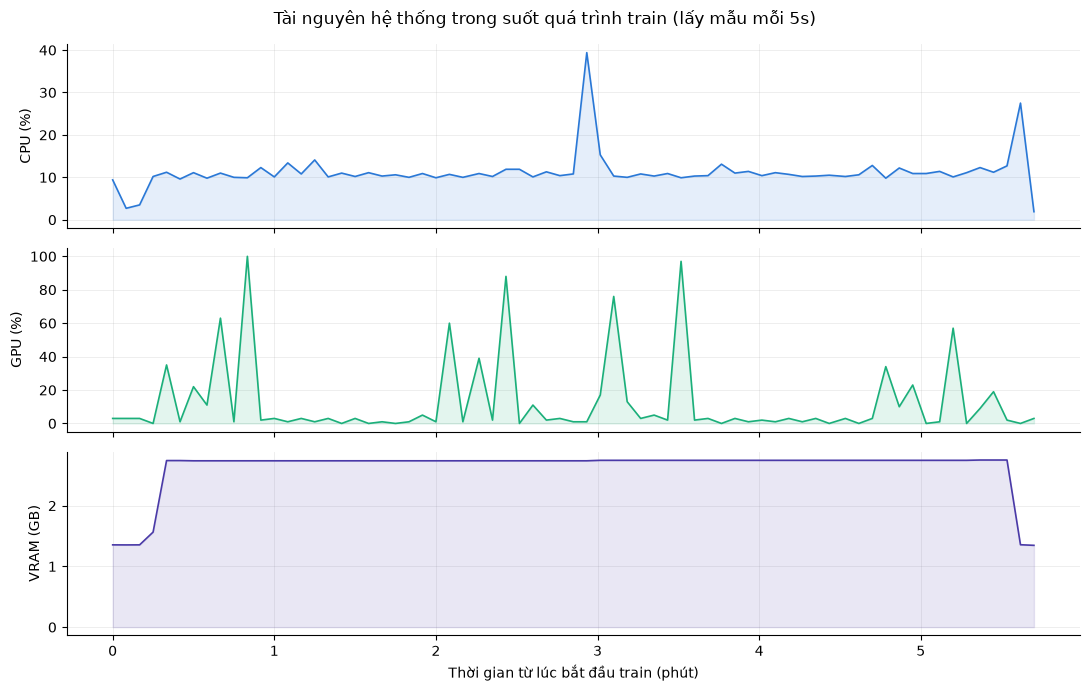

In [7]:
RES_COLORS = {"cpu": "#2a78d6", "gpu": "#1baf7a", "vram": "#4a3aa7"}
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
t = (res_df["timestamp"] - res_df["timestamp"].iloc[0]).dt.total_seconds() / 60
for ax, col, label, color in zip(
    axes, ["cpu_pct", "gpu_util_pct", "gpu_mem_used_mb"],
    ["CPU (%)", "GPU (%)", "VRAM (GB)"], [RES_COLORS["cpu"], RES_COLORS["gpu"], RES_COLORS["vram"]],
):
    y = res_df[col] / 1024 if col == "gpu_mem_used_mb" else res_df[col]
    ax.plot(t, y, color=color, linewidth=1.2)
    ax.fill_between(t, y, alpha=0.12, color=color)
    ax.set_ylabel(label)
axes[-1].set_xlabel("Thời gian từ lúc bắt đầu train (phút)")
fig.suptitle("Tài nguyên hệ thống trong suốt quá trình train (lấy mẫu mỗi 5s)")
fig.tight_layout()
fig.savefig(FIG_DIR / "vehicle_type_resource_usage.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Phân tích quá trình train: đường loss/accuracy theo epoch

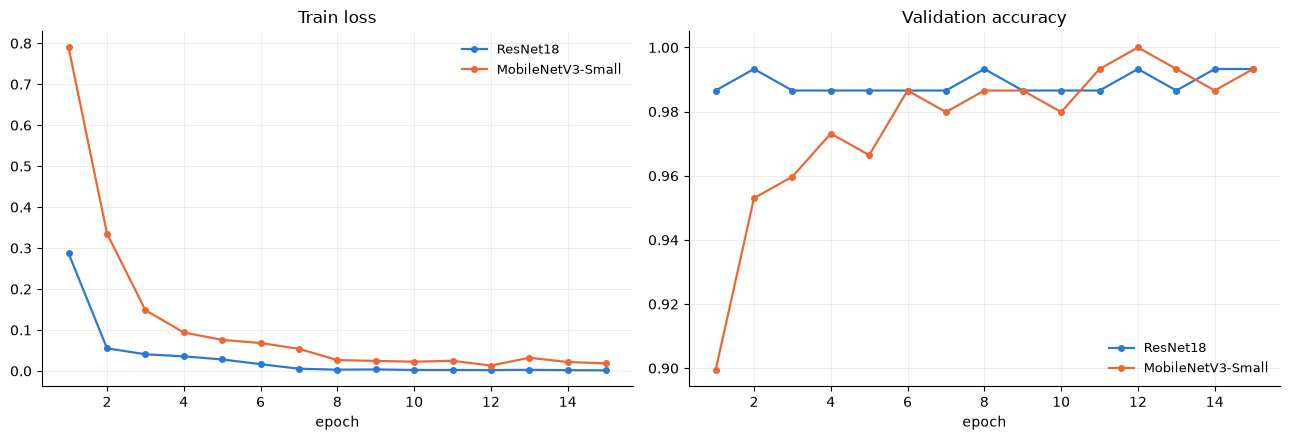

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for model in MODELS:
    h = histories[model]
    epochs = [e["epoch"] for e in h["epochs"]]
    train_loss = [e["train_loss"] for e in h["epochs"]]
    val_acc = [e["val_acc"] for e in h["epochs"]]
    c = MODEL_COLORS[model]
    axes[0].plot(epochs, train_loss, marker="o", label=MODEL_LABELS[model], markersize=4, color=c, linewidth=1.6)
    axes[1].plot(epochs, val_acc, marker="o", label=MODEL_LABELS[model], markersize=4, color=c, linewidth=1.6)
axes[0].set_title("Train loss"); axes[0].set_xlabel("epoch"); axes[0].legend(fontsize=9, frameon=False)
axes[1].set_title("Validation accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend(fontsize=9, frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "vehicle_type_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

**Nhận xét:** cả 2 kiến trúc hội tụ nhanh (loss giảm mạnh trong 2-3 epoch đầu).
ResNet18 ổn định hơn ngay từ epoch 1 (val_acc 0,987), trong khi MobileNetV3-Small cần
~6 epoch mới bắt kịp (0,90 → 0,99), và dao động rõ hơn suốt quá trình train — dấu hiệu
mạng nhỏ nhạy hơn với các đợt batch có nhiều ảnh lớp `truck` (ít dữ liệu) hơn.

## 5. Kết quả cuối trên tập test: so sánh 2 kiến trúc

In [9]:
summary_rows = []
for model, h in histories.items():
    t = h["test"]
    summary_rows.append({
        "Model": MODEL_LABELS[model],
        "Accuracy": round(t["accuracy"], 4), "F1-macro": round(t["f1_macro"], 4),
        "Params": h["params"], "ONNX (MB)": h["onnx_size_mb"], "CPU (ms)": round(h["cpu_ms"], 2),
    })
summary_df = pd.DataFrame(summary_rows)

def style_best(data):
    styles = pd.DataFrame("", index=data.index, columns=data.columns)
    for col in ("Accuracy", "F1-macro"):
        best_idx = data[col].idxmax()
        styles.loc[best_idx, col] = "background-color: #d7ecc8; font-weight: bold"
    return styles

display(
    summary_df.style
    .apply(style_best, axis=None)
    .format({"Accuracy": "{:.2%}", "F1-macro": "{:.2%}", "Params": "{:,}", "ONNX (MB)": "{:.2f}", "CPU (ms)": "{:.2f}"})
    .hide(axis="index")
    .set_caption("Kết quả trên tập test - màu xanh lá cây = tốt nhất")
)

Model,Accuracy,F1-macro,Params,ONNX (MB),CPU (ms)
ResNet18,98.66%,96.19%,"11,178,051",44.70,8.19
MobileNetV3-Small,97.99%,95.71%,"1,520,931",6.09,4.22


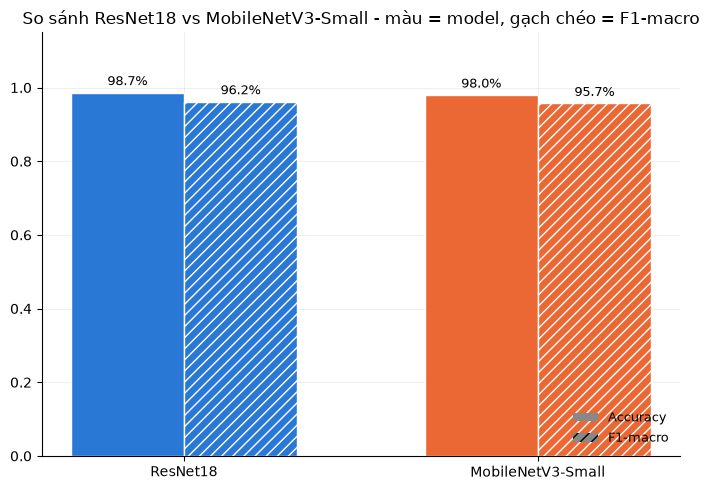

In [10]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(7, 5))
width = 0.32
for i, model in enumerate(MODELS):
    r = summary_df[summary_df["Model"] == MODEL_LABELS[model]].iloc[0]
    c = MODEL_COLORS[model]
    ax.bar(i - width / 2, r["Accuracy"], width, color=c, edgecolor="white")
    ax.bar(i + width / 2, r["F1-macro"], width, color=c, hatch="///", edgecolor="white")
    ax.text(i - width / 2, r["Accuracy"] + 0.02, f"{r['Accuracy']:.1%}", ha="center", fontsize=9)
    ax.text(i + width / 2, r["F1-macro"] + 0.02, f"{r['F1-macro']:.1%}", ha="center", fontsize=9)
ax.set_xticks(range(len(MODELS))); ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS])
ax.set_ylim(0, 1.15)
legend_elems = [Patch(facecolor="#888", label="Accuracy"), Patch(facecolor="#888", hatch="///", label="F1-macro")]
ax.legend(handles=legend_elems, fontsize=9, frameon=False, loc="lower right")
ax.set_title("So sánh ResNet18 vs MobileNetV3-Small - màu = model, gạch chéo = F1-macro")
fig.tight_layout()
fig.savefig(FIG_DIR / "vehicle_type_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Ma trận nhầm lẫn từng kiến trúc

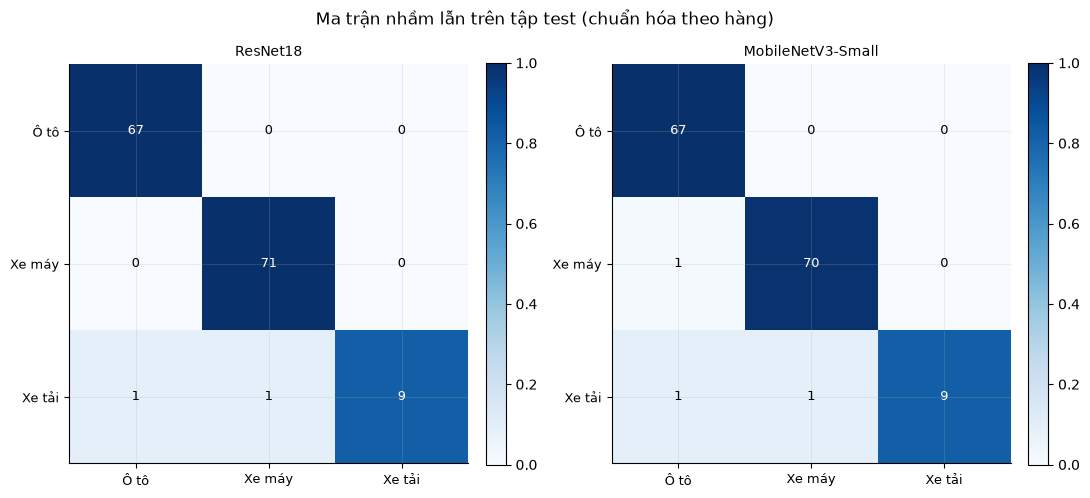

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, model in zip(axes, MODELS):
    h = histories[model]
    cm = np.array(h["test"]["confusion_matrix"])
    classes = h["class_names"]
    classes_display = [CLASS_LABELS.get(c, c) for c in classes]
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes_display, fontsize=9)
    ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes_display, fontsize=9)
    ax.set_title(MODEL_LABELS[model], fontsize=10)
    for i in range(len(classes)):
        for j in range(len(classes)):
            val = cm[i, j]
            color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i, str(val), ha="center", va="center", fontsize=9, color=color)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Ma trận nhầm lẫn trên tập test (chuẩn hóa theo hàng)")
fig.tight_layout()
fig.savefig(FIG_DIR / "vehicle_type_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

**Đọc ma trận này kỹ hơn bình thường:** để ý riêng hàng/cột `Xe tải` — lớp này chỉ có
11 ảnh test, nên 1-2 ảnh đoán sai đã đổi hẳn con số accuracy theo lớp. Đừng kết luận
"model học tốt xe tải" chỉ từ accuracy tổng thể mà không nhìn hàng riêng của nó. Thực tế:
ResNet18 sai 2/11 ảnh xe tải (1 đoán thành car, 1 thành motorbike), MobileNetV3-Small
cũng sai 2/11 tương tự — cả 2 lớp car/motorbike đều đúng tuyệt đối (67/67 và 71/71 hoặc
70/71).

## 6. Kiểm tra ngoài phân phối (out-of-distribution) — bài kiểm tra quan trọng nhất

Accuracy trên tập test ở mục 5 **không đủ để tin cậy** vì test set lấy mẫu từ đúng các
nguồn đã dùng để train. Bài kiểm tra thật: chạy model trên 12 ảnh car/motorbike lấy từ
`Dieu_*`/`Hung_*`, biết chắc nhãn qua xem tay, **xác nhận không nằm trong danh sách đã
dùng train** — script `src/ml/sanity_check_vehicle_type_ood.py`.

| Model | Trước khi trộn 2 nguồn/lớp | Sau khi trộn 2 nguồn/lớp |
|---|---|---|
| ResNet18 | 1/13 đúng (8%) — mọi ảnh đường phố đều đoán "truck" | 12/12 đúng (100%) |
| MobileNetV3-Small | 1/13 đúng (8%) | 11/12 đúng (92%) |

Kết luận: accuracy tập test một mình không phát hiện được lỗi học tắt theo phong cách ảnh
(spurious correlation) khi mỗi lớp chỉ có 1 nguồn dữ liệu — bắt buộc phải kiểm thêm bằng
ảnh khác nguồn hoàn toàn.

## 7. Tổng kết

- ResNet18 đạt accuracy 98,66% (F1-macro 96,19%), MobileNetV3-Small đạt 97,99%
  (F1-macro 95,71%) trên tập test — sát nhau, ResNet18 nhỉnh hơn chút ở lớp `truck`.
- Về chi phí: ResNet18 nặng hơn MobileNetV3-Small ~7,3 lần tham số (11,2M so với 1,5M),
  ~7,3 lần dung lượng ONNX (44,7MB so với 6,1MB), CPU chậm hơn ~2 lần (8,2ms so với
  4,2ms/ảnh). Với accuracy gần tương đương, MobileNetV3-Small hợp lý hơn cho triển khai
  Edge (Raspberry Pi 5).
- **Phát hiện quan trọng nhất của thử nghiệm này không phải là accuracy, mà là quy trình
  đánh giá**: lần train đầu (mỗi lớp car/motorbike chỉ 1 nguồn ảnh) cho accuracy 100% trên
  test set nhưng hoàn toàn không dùng được — model học theo phong cách ảnh, không phải
  hình dáng xe, chứng minh bằng bộ kiểm tra ngoài phân phối (mục 6). Sau khi trộn thêm ảnh
  đường phố vào car/motorbike, accuracy tập test giảm nhẹ (98,7%/98,0% so với 100%) nhưng
  đây mới là con số đáng tin, vì model giờ generalize được sang ảnh chưa từng thấy.
- Việc còn thiếu: lớp `bus`; và lớp `truck` vẫn chỉ có phong cách "đường phố", chưa có ảnh
  cận cảnh kiểu camera cổng giống car/motorbike (chưa tìm được nguồn tương đương
  carlong_/greenpack_ cho xe tải) — rủi ro accuracy thật trên camera cổng có thể thấp hơn
  số đo ở đây.
- Đề xuất: thay thế bước dùng nhãn lớp COCO của YOLOv8n pretrained trong
  `predict_vehicle.detect_vehicle_crop` bằng model MobileNetV3-Small vừa huấn luyện; YOLOv8n
  vẫn giữ lại chỉ để tìm/cắt vùng xe (việc này nó vẫn làm tốt).